# Task4: 閸楁洘鐦悧褰掆攳閸斻劋绗岄柅鈧惄绋垮叡

1. 閻劌鐢崣鍌涙殶閻?`rx(theta)` 鐞涖劎銇氶惄顔界垼閺冨娴嗙憴鎺嬧偓淇搉2. 閻?`control_scale` 娴ｆ粈璐熸す鍗炲З瀵搫瀹崇€规碍鐖ｉ弮瀣尦閿涘矁顫囩€电啿鈧粌鎳℃禒銈堫潡鎼达腹鈧繂鎷伴垾婊冪杽闂勫懏妫嗘潪顒冾潡鎼达腹鈧繀绠ｉ梻瀵告畱閸忓磭閮撮妴淇搉

In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from workflow import create_model


def pairs_to_complex(values):
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 1:
        return arr.astype(complex)
    return arr[:, 0] + 1j * arr[:, 1]


TASK_DIR = Path("task4")
if not (TASK_DIR / "task.yaml").exists():
    TASK_DIR = Path("examples/noise_simulation_tests/task4")
model = create_model(task_config=TASK_DIR / 'task.yaml')
model.run_all()


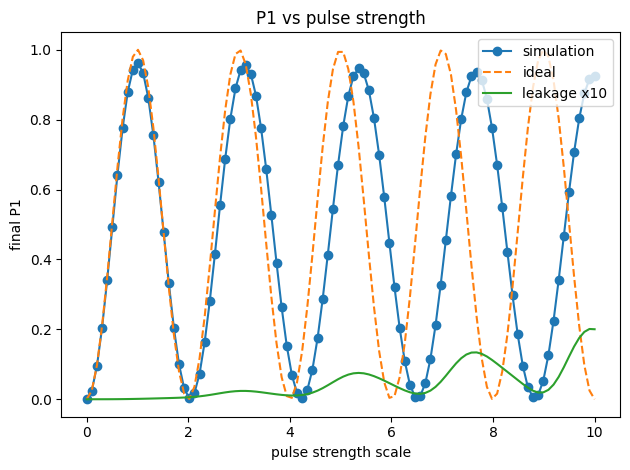

In [5]:
pulse_scales = np.linspace(0, 10.0, 100)
p1_list = []
p2_list = []

for scale in pulse_scales:
    # 閺€?gate 鐎电懓绨查惃鍕埠娑撯偓妞瑰崬濮╁鍝勫缂傗晜鏂乗n    model.device.device["control_scale"] = float(scale)

    # 闁插秵鏌婃潻鎰攽
    model.run_all()

    analysis = model.results.analyses["analyser_0"]
    p1 = float(analysis.metrics["population"]["values"]["1"][-1])
    p2 = float(analysis.metrics["population"]["values"]["2"][-1])
    p1_list.append(p1)
    p2_list.append(p2)


plt.plot(pulse_scales, p1_list, marker='o', label="simulation")
plt.plot(
    pulse_scales,
    np.sin(np.pi * pulse_scales / 2.0) ** 2,
    "--",
    label="ideal",
)
plt.plot(pulse_scales, 10 * np.array(p2_list), label="leakage x10")
plt.xlabel("pulse strength scale")
plt.ylabel("final P1")
plt.title("P1 vs pulse strength")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


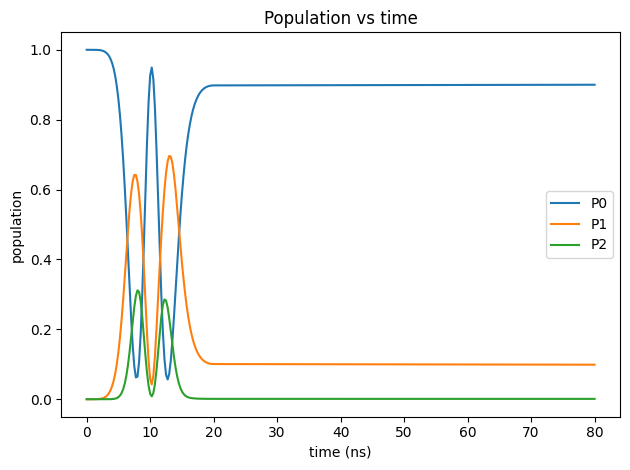

In [7]:
model.device.device["control_scale"] = 4.0
model.run_all()

analysis = model.results.analyses["analyser_0"]
t  = np.asarray(analysis.metrics["population"]["times"]) * 1e9
p0 = np.asarray(analysis.metrics["population"]["values"]["0"])
p1 = np.asarray(analysis.metrics["population"]["values"]["1"])
p2 = np.asarray(analysis.metrics["population"]["values"]["2"])

plt.plot(t, p0, label="P0")
plt.plot(t, p1, label="P1")
plt.plot(t, p2, label="P2")
plt.xlabel("time (ns)")
plt.ylabel("population")
plt.title("Population vs time")
plt.legend()
plt.tight_layout()
plt.show()